<a href="https://colab.research.google.com/github/sanyagusain19/Deep_Learning/blob/main/regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import seaborn as sns

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

from tensorflow.keras.optimizers import Adam

In [4]:
X, y = make_moons(100, noise=0.2, random_state=2)

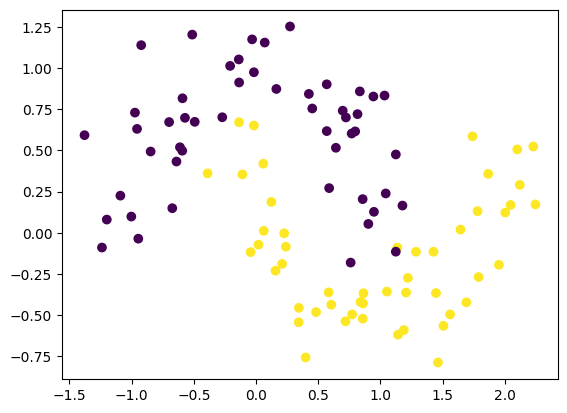

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1],c=y)

In [6]:
model1= Sequential()
model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1, activation="sigmoid"))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
adam = Adam(learning_rate=0.001)
model1.compile(loss="binary_crossentropy", optimizer=adam, metrics=['accuracy'])
history1 = model1.fit(X,y, epochs=2000, validation_split=0.2, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


(-1.0, 2.0)

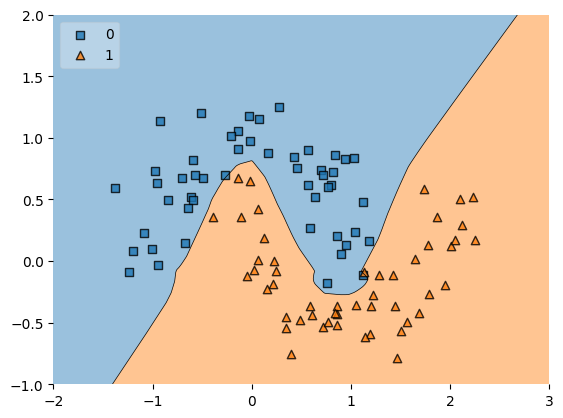

In [9]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype("int"), clf=model1,legend=2)
plt.xlim(-2,3)
plt.ylim(-1,2)

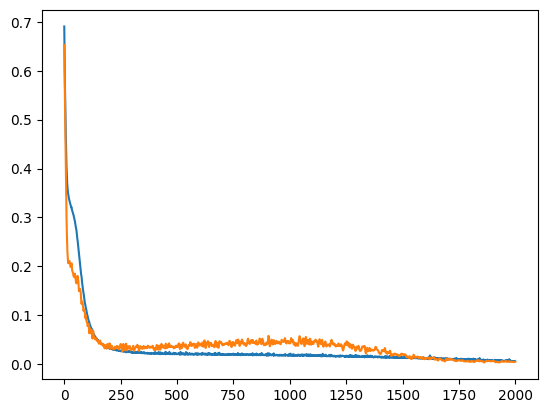

In [10]:
plt.plot(history1.history["loss"])
plt.plot(history1.history["val_loss"])

In [11]:
model2= Sequential()
model2.add(Dense(128,input_dim=2, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.l2(0.05)))
model2.add(Dense(128, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1, activation="sigmoid"))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
adam = Adam(learning_rate=0.001)
model2.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])
history=model2.fit(X,y, epochs=2000, validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step


(-1.0, 2.0)

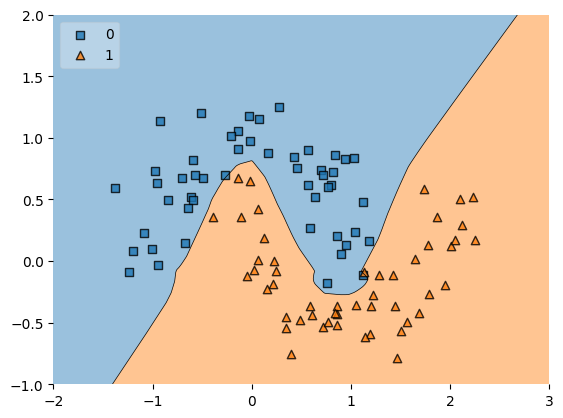

In [14]:
plot_decision_regions(X,y.astype("int"), clf=model1,legend=2)
plt.xlim(-2,3)
plt.ylim(-1,2)

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

In [22]:
model1_weights= model1.get_weights()[0].reshape(256)
model2_weights=model2.get_weights()[0].reshape(256)

In [19]:
model2_weights.reshape(256)

array([ 1.85743418e-35,  4.48123013e-35,  1.10088983e-34,  4.17573705e-36,
        6.64777527e-35,  1.02855457e-34, -1.04101859e-01, -2.01090202e-01,
        4.54249971e-11,  2.22940166e-35, -1.90277595e-35,  8.32146628e-35,
       -5.67183601e-35, -1.10837156e-34, -9.64531915e-35, -3.49158786e-35,
       -5.49771246e-35, -1.01090677e-34,  1.42560708e-32,  1.55286147e-35,
        5.05561064e-35, -7.04851438e-35,  3.61694044e-35, -3.08698133e-35,
       -1.05517309e-34, -7.12654470e-35,  3.71771898e-06, -2.19591202e-05,
       -2.25371066e-35,  8.05831683e-35, -4.75805216e-35, -2.15486035e-01,
       -2.04028443e-01,  4.08954944e-35,  5.36257883e-35, -2.44283051e-35,
       -2.80591879e-37,  4.67004936e-35, -6.84713808e-35, -4.80971077e-35,
        3.17900509e-35, -1.09148037e-34,  8.09438408e-35, -1.97609693e-01,
       -5.42485047e-36,  1.04924373e-01,  1.24475097e-08,  3.89395361e-35,
       -1.90041259e-01, -7.20513752e-36, -5.60629416e-35,  6.04507153e-37,
        6.01708122e-35,  

In [20]:
model1_weights

array([[ 2.64256567e-01, -4.37807858e-01,  2.07473651e-01,
        -3.52216303e-01,  2.14288771e-01, -4.02750403e-01,
         3.00701737e-01, -3.44886601e-01, -4.60761040e-01,
         8.88721198e-02, -4.75739002e-01,  9.10186768e-02,
         9.76232812e-03,  2.34457582e-01,  1.99453980e-01,
         4.04939651e-02, -3.77408005e-02, -5.02483785e-01,
        -5.78798428e-02, -4.47723210e-01, -5.40012941e-02,
         1.46883309e-01, -3.13734651e-01, -4.02423739e-01,
         1.45733887e-02, -5.13539076e-01, -1.71911865e-02,
        -4.98214990e-01, -4.12501007e-01, -1.23508852e-02,
         2.64407605e-01,  2.40771145e-01,  1.66553527e-01,
         1.34980962e-01,  1.59332693e-01, -3.87222111e-01,
         2.21645921e-01, -4.41941351e-01, -4.77985926e-02,
         3.54805067e-02,  2.05855846e-01, -1.68495513e-02,
        -4.40497011e-01,  2.90298492e-01,  1.86949775e-01,
         8.49903002e-03,  2.01415077e-01,  2.73480695e-02,
         2.30511412e-01, -8.58348422e-03,  1.05185686e-0

<Axes: >

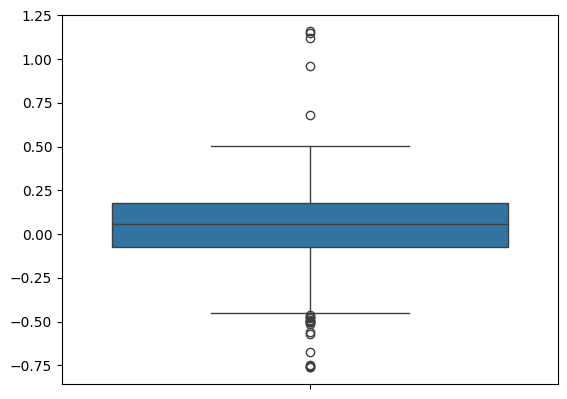

In [23]:
sns.boxplot(model1_weights)

<Axes: >

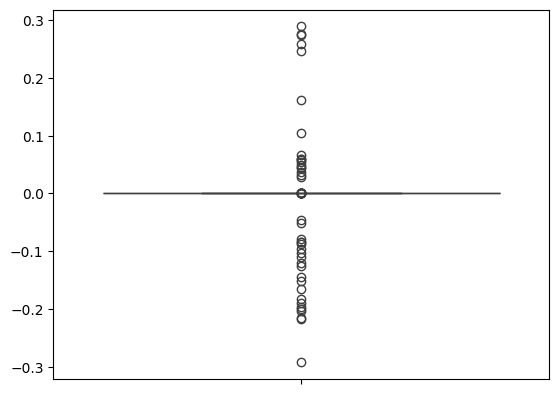

In [24]:
sns.boxplot(model2_weights)

In [27]:
model1_weights.max()

np.float32(1.1594274)

In [28]:
model2_weights.max()

np.float32(0.28929937)

/tmp/ipykernel_1145/4034192358.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weights)
/tmp/ipykernel_1145/4034192358.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weights)


<Axes: ylabel='Density'>

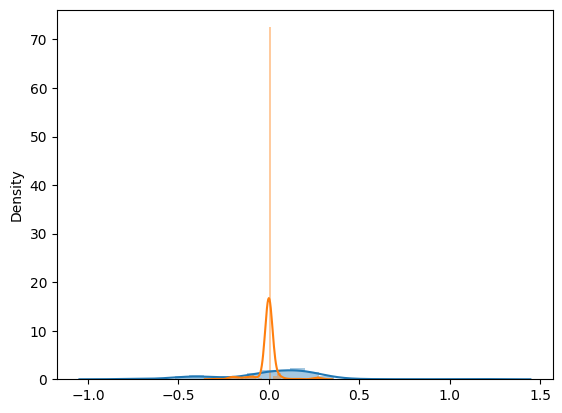

In [29]:
sns.distplot(model1_weights)
sns.distplot(model2_weights)